In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

import util

from plot_setup import *

FOLDER = "/Users/brendan/Projects/trails/data/"


In [4]:
datafiles = [
    # "optimality|2025-07-08/data.json",
    "optimality|2025-11-21/data.json",
]

dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)

ratios: [10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0 90.0 100.0 110.0 120.0 130.0
 140.0 150.0 160.0 170.0 180.0 190.0 200.0]
patch recovery: [0.001]
max costs: [2.0 8.0]
boundary conditions: ['SOLID']
num locations: [8 16 32]
random walker seeds: 2
random locations seeds: 2
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_FIXED']
settings.X : [100]
steps: 10000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


In [5]:
EXAMPLE_RATIOS = [60, 90, 150]
STEPS = 10000
COLORS = [sns.color_palette("rocket")[1], sns.color_palette("rocket")[3], sns.color_palette("rocket")[5]]

In [6]:
# # TODO - load the right dataframe for these.

# example_df = df[
#     (df["steps"] == STEPS) &
#     (df["settings.numLocations"] == 32) &
#     (df["settings.randomSeedLocations"] == 1) &
#     (df["settings.randomSeedWalkers"] == 2) &
#     (df["settings.maxCost"] == 2.0) &
#     (df["ratio"].isin(EXAMPLE_RATIOS))
# ]

# LENGTH = 4
# fig, axs = plt.subplots(1, len(EXAMPLE_RATIOS), figsize=(len(EXAMPLE_RATIOS)*LENGTH, LENGTH), dpi=DPI)
# # plt.subplots_adjust(wspace=0.5, hspace=0.2)
# for i, ratio in enumerate(EXAMPLE_RATIOS):
#     row = example_df[(example_df["ratio"] == ratio) & (example_df["steps"] == STEPS)].iloc[0]

#     axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP)
#     axs[i].axis('off')

In [7]:
def add_fig(subfig):
    ax = subfig.subplots()
    _df = df[
        (df["steps"] % 2000 == 0) &
        (df["steps"] == 10000) &
        (df["settings.numLocations"] == 32) &
        # (df["settings.randomSeedLocations"] == 1) &
        (df["settings.maxCost"] == 2.0)
        
    ]
    
    # fig, ax = plt.subplots(figsize=(one_column_width, 80/mm_to_inch))
    
    p = sns.scatterplot(
        data=_df,
        ax=ax,
        y="averageTravelCost",
        x="totalImprovement",
        # size="ratio",
        # col="settings.numLocations",
        # row="settings.randomSeedLocations",
        hue="ratio",
        # kind="scatter",
        style="settings.randomSeedLocations",
        legend=False,
    )
    
    # ax.set_xticks([])
    # ax.set_yticks([])
        
    
    ax.set_xlabel("Amount of Trail", fontsize=9)
    ax.set_ylabel("Travel Costs", fontsize=9)


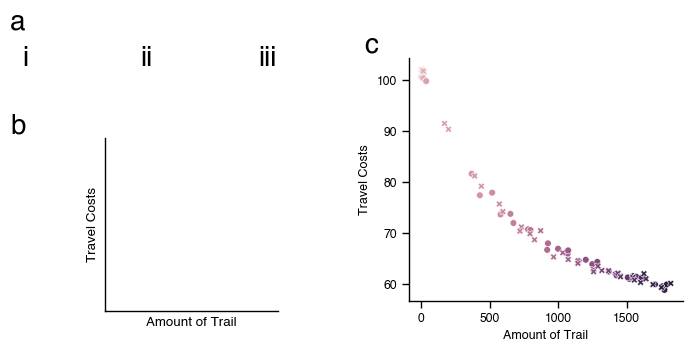

In [16]:
fig = plt.figure(figsize=(two_column_width, 80/mm_to_inch))
left, right = fig.subfigures(1, 2)
l_top, l_bot = left.subfigures(2, 1, height_ratios=[2, 5])
add_letter(l_top, 0, 0.9, "a")
add_letter(l_bot, 0, 0.9, "b")

l_top_split = l_top.subfigures(1, 3)
for i, num in enumerate(["i", "ii", "iii"]):
    add_letter(l_top_split[i], 0.1, 0.5, num)

# setting up empty axes for the example/schematics.
ax = l_bot.subplots()
ax.set_xlabel("Amount of Trail")
ax.set_ylabel("Travel Costs")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")


add_fig(right)
add_letter(right, 0, 0.9, "c")

fig.savefig("figures/2untouched.svg", bbox_inches="tight")
fig.savefig("figures/2untouched.png", bbox_inches="tight")